In [1]:
import pandas as pd
import matplotlib.pyplot as plt                                                                                                                       
import seaborn as sns                                                                                                                                 

### Задание 1
Импортировать датасет (Исходные данные можно выбрать самостоятелно на kaggle.com, либо взять один из файлов, прикрепленных к заданию)

In [2]:
df = pd.read_csv('../data/StudentPerformanceFactors.csv')
print(type(df))

<class 'pandas.DataFrame'>


### Задание 2
Проверить данные на пропуски и наличие аномальных значений, использовать для этого статистические методы и средства графической визуализации(графики распределения, диаграммы, графики типа BoxPlot, тепловые карты и т.п.). Заполнить пропуски и устранить выбросы. Проверить, при помощи графических средств, что пропуски и аномальные значения отсутствуют

In [3]:
# пропуски
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

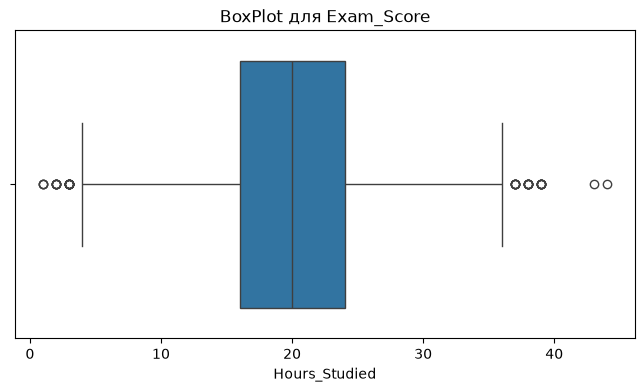

In [4]:
plt.figure(figsize=(8, 4))                                                                                                                            
sns.boxplot(x=df['Hours_Studied'])                                                                                                                       
plt.title("BoxPlot для Exam_Score")                                                                                                                   
plt.show() 

Столбец 'Teacher_Quality' заполнен значением: Medium
Столбец 'Parental_Education_Level' заполнен значением: High School
Столбец 'Distance_from_Home' заполнен значением: Near
Всего пропусков в датасете после обработки: 0

Размер датасета ДО удаления выбросов: (6607, 20)
Размер датасета ПОСЛЕ удаления выбросов: (6473, 20)


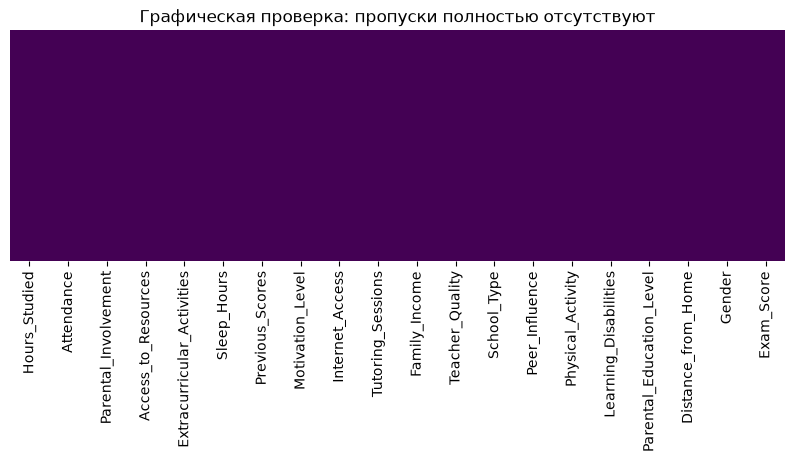

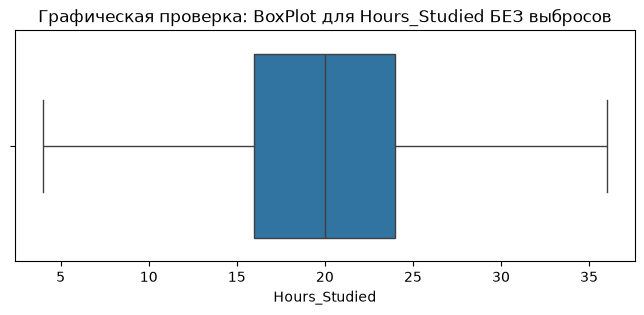

In [5]:
# =========================================================================
# 1. ЗАПОЛНЕНИЕ ПРОПУСКОВ
# =========================================================================
# Для категориальных столбцов заполняем пропуски самым частым значением (модой)
columns_with_nulls = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in columns_with_nulls:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"Столбец '{col}' заполнен значением: {mode_value}")

print("Всего пропусков в датасете после обработки:", df.isna().sum().sum())

# =========================================================================
# 2. УСТРАНЕНИЕ ВЫБРОСОВ (IQR METHOD)
# =========================================================================
print("\nРазмер датасета ДО удаления выбросов:", df.shape)

for col in ['Hours_Studied', 'Exam_Score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Оставляем только строки без выбросов
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Размер датасета ПОСЛЕ удаления выбросов:", df.shape)

# =========================================================================
# 3. ГРАФИЧЕСКАЯ ПРОВЕРКА ОТСУТСТВИЯ ПРОПУСКОВ И ВЫБРОСОВ
# =========================================================================
# Проверка 1: Тепловая карта пропусков (должна быть идеально монолитной, без штрихов)
plt.figure(figsize=(10, 3))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Графическая проверка: пропуски полностью отсутствуют")
plt.show()

# Проверка 2: BoxPlot (усы на месте, а кружочки-выбросы за ними исчезли)
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Hours_Studied'])
plt.title("Графическая проверка: BoxPlot для Hours_Studied БЕЗ выбросов")
plt.show()


### Задание 3
Сгенерировать новые признаки (не менее двух), а также применить кодирование категориальных признаков (применить OHE-кодирование, бинаризацию признаков и др.)

In [6]:
# =========================================================================
# 1. ГЕНЕРАЦИЯ НОВЫХ ПРИЗНАКОВ (FEATURE ENGINEERING)
# =========================================================================

# Признак 1: Общая учебная нагрузка (самостоятельные часы + часы с репетитором с весовым коэфф.)
df['Total_Study_Effort'] = (df['Hours_Studied'] + (df['Tutoring_Sessions'] * 1.5)).round(1)

# Признак 2: Ожидаемый потенциал успеваемости (прошлые баллы, взвешенные по посещаемости)
df['Attendance_Weighted_Score'] = ((df['Attendance'] / 100) * df['Previous_Scores']).round(2)

# Признак 3: Баланс учёбы и сна (доля часов учёбы относительно недельного сна)
df['Study_to_Sleep_Ratio'] = (df['Hours_Studied'] / (df['Sleep_Hours'] * 7)).round(3)

print("1. Новые сгенерированные признаки (первые 5 строк):")
print(df[['Hours_Studied', 'Tutoring_Sessions', 'Total_Study_Effort', 'Attendance_Weighted_Score', 'Study_to_Sleep_Ratio']].head())

# =========================================================================
# 2. БИНАРИЗАЦИЯ ПРИЗНАКОВ (BINARY ENCODING: 0 / 1)
# =========================================================================
# Преобразуем признаки с двумя исходами в бинарные (0 и 1)
binary_cols_yes_no = ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities']
for col in binary_cols_yes_no:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['School_Type'] = df['School_Type'].map({'Public': 0, 'Private': 1})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# =========================================================================
# 3. ПОРЯДКОВОЕ КОДИРОВАНИЕ (ORDINAL ENCODING)
# =========================================================================
# Для категорий с естественным рангом (Low < Medium < High)
ordinal_mappings = {
    'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources':  {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level':     {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income':        {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality':      {'Low': 0, 'Medium': 1, 'High': 2},
    'Distance_from_Home':   {'Near': 0, 'Moderate': 1, 'Far': 2}
}

for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)

# =========================================================================
# 4. ONE-HOT ENCODING (OHE-КОДИРОВАНИЕ ДЛЯ НОМИНАЛЬНЫХ КАТЕГОРИЙ)
# =========================================================================
# Для номинальных признаков без строгого ранжирования используем фиктивные переменные (pd.get_dummies)
nominal_cols = ['Peer_Influence', 'Parental_Education_Level']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print("\n2. Итоговый размер датасета после кодирования:", df.shape)
print("Все типы данных в таблице стали числовыми:")
print(df.dtypes.value_counts())

df.head()


1. Новые сгенерированные признаки (первые 5 строк):
   Hours_Studied  Tutoring_Sessions  Total_Study_Effort  \
0             23                  0                23.0   
1             19                  2                22.0   
2             24                  2                27.0   
3             29                  1                30.5   
4             19                  3                23.5   

   Attendance_Weighted_Score  Study_to_Sleep_Ratio  
0                      61.32                 0.469  
1                      37.76                 0.339  
2                      89.18                 0.490  
3                      87.22                 0.518  
4                      59.80                 0.452  

2. Итоговый размер датасета после кодирования: (6473, 25)
Все типы данных в таблице стали числовыми:
int64      22
float64     3
Name: count, dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Distance_from_Home,Gender,Exam_Score,Total_Study_Effort,Attendance_Weighted_Score,Study_to_Sleep_Ratio,Peer_Influence_Neutral,Peer_Influence_Positive,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate
0,23,84,0,2,0,7,73,0,1,0,...,0,0,67,23.0,61.32,0.469,0,1,1,0
1,19,64,0,1,0,8,59,0,1,2,...,1,1,61,22.0,37.76,0.339,0,0,0,0
2,24,98,1,1,1,7,91,1,1,2,...,0,0,74,27.0,89.18,0.490,1,0,0,1
3,29,89,0,1,1,8,98,1,1,1,...,1,0,71,30.5,87.22,0.518,0,0,1,0
4,19,92,1,1,1,6,65,1,1,3,...,0,1,70,23.5,59.80,0.452,1,0,0,0


### Задание 4
Выполнить стандартизацию и/или нормализацию данных.

1. Пример нормализованных признаков (диапазон [0, 1]):
     Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
min            0.0         0.0          0.0              0.0   
max            1.0         1.0          1.0              1.0   

     Tutoring_Sessions  Physical_Activity  Total_Study_Effort  \
min                0.0                0.0                 0.0   
max                1.0                1.0                 1.0   

     Attendance_Weighted_Score  Study_to_Sleep_Ratio  
min                        0.0                   0.0  
max                        1.0                   1.0  

2. Пример стандартизированных признаков (mean ~ 0, std ~ 1):
      Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
mean            0.0        -0.0         -0.0              0.0   
std             1.0         1.0          1.0              1.0   

      Tutoring_Sessions  Physical_Activity  Total_Study_Effort  \
mean                0.0               -0.0                -0.0   
s

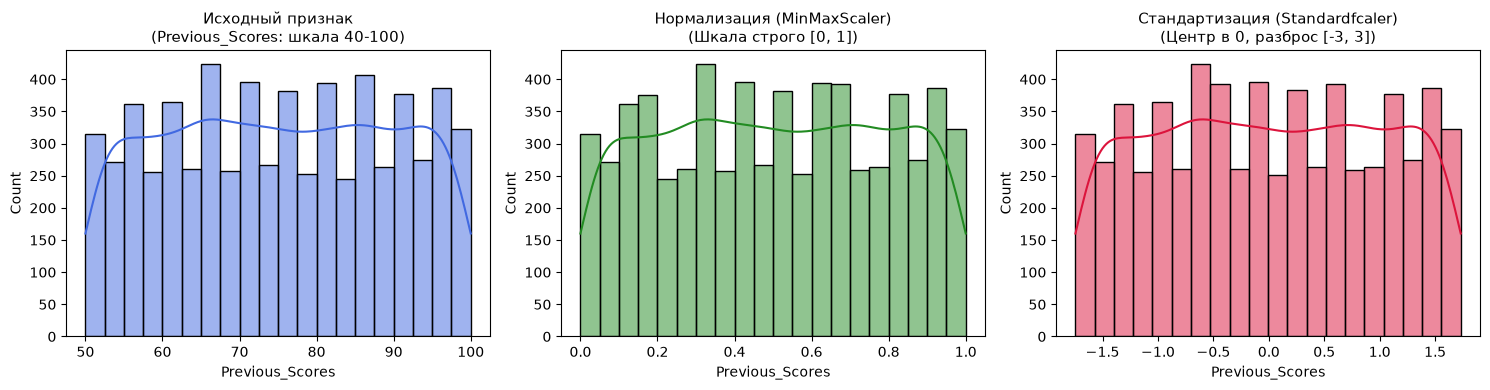

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. Разделяем датасет на матрицу признаков (X) и целевую переменную (y)
# Целевую переменную Exam_Score не масштабируем, чтобы сохранить интерпретируемость оценок
X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']

# Список непрерывных числовых признаков с разным масштабом
numeric_features = [
    'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
    'Tutoring_Sessions', 'Physical_Activity', 'Total_Study_Effort',
    'Attendance_Weighted_Score', 'Study_to_Sleep_Ratio'
]

# =========================================================================
# 2. НОРМАЛИЗАЦИЯ (MinMaxScaler: сжатие в диапазон [0, 1])
# =========================================================================
# Формула: X_norm = (X - X_min) / (X_max - X_min)
min_max_scaler = MinMaxScaler()
X_normalized = X.copy()
X_normalized[numeric_features] = min_max_scaler.fit_transform(X[numeric_features])

print("1. Пример нормализованных признаков (диапазон [0, 1]):")
print(X_normalized[numeric_features].describe().loc[['min', 'max']])

# =========================================================================
# 3. СТАНДАРТИЗАЦИЯ (Standardfcaler: среднее = 0, дисперсия/ст. откл = 1)
# =========================================================================
# Формула: z = (X - mu) / sigma
std_scaler = StandardScaler()
X_standardized = X.copy()
X_standardized[numeric_features] = std_scaler.fit_transform(X[numeric_features])

print("\n2. Пример стандартизированных признаков (mean ~ 0, std ~ 1):")
print(X_standardized[numeric_features].describe().round(3).loc[['mean', 'std']])

# =========================================================================
# 4. ГРАФИЧЕСКОЕ СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ ДО И ПОСЛЕ МАСШТАБИРОВАНИЯ
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Исходный признак
sns.histplot(X['Previous_Scores'], kde=True, ax=axes[0], color='royalblue', bins=20)
axes[0].set_title('Исходный признак\n(Previous_Scores: шкала 40-100)', fontsize=11)

# Нормализация
# Нормализация
sns.histplot(X_normalized['Previous_Scores'], kde=True, ax=axes[1], color='forestgreen', bins=20)
axes[1].set_title('Нормализация (MinMaxScaler)\n(Шкала строго [0, 1])', fontsize=11)

# Стандартизация
sns.histplot(X_standardized['Previous_Scores'], kde=True, ax=axes[2], color='crimson', bins=20)
axes[2].set_title('Стандартизация (Standardfcaler)\n(Центр в 0, разброс [-3, 3])', fontsize=11)

plt.tight_layout()
plt.show()
